# 1. Mission et contexte

La direction RH veut comprendre où et pourquoi l'attrition se concentre, et si des écarts de rémunération existent entre profils comparables. Avant de livrer un dashboard, je m'assure que les 35 champs du jeu de données ([IBM HR Analytics Employee Attrition](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset), 1470 collaborateurs) sont fiables : c'est l'objet du catalogue de données (`DATA_CATALOG.md`). Le besoin est ensuite formalisé en backlog (`BACKLOG.md`), et chaque KPI de ce notebook répond à une user story précise.

Ce jeu de données est fictif, généré par IBM pour démontrer son outil Watson Analytics, pas une extraction réelle de SIRH. Les chiffres qui suivent illustrent donc une méthode (catalogue, requêtage, priorisation par preuve statistique), pas un diagnostic RH généralisable à une vraie entreprise.

Un guide utilisateur autonome pour lire le dashboard est disponible dans `USER_GUIDE.md`.

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

df = pd.read_csv("../data/hr_employee_attrition.csv", encoding="utf-8-sig")
df.shape

(1470, 35)

In [2]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# 2. KPIs retenus

Pour répondre à la mission (où et pourquoi l'attrition se concentre, écarts de rémunération), je retiens quatre KPIs avant de toucher au reste du code :

- **Taux d'attrition par département et par poste** : localise le problème avant d'en chercher la cause.
- **Facteurs associés à l'attrition** (heures supplémentaires, satisfaction au poste, ancienneté sans promotion) : explique une partie du "pourquoi", au-delà du simple constat.
- **Écart de revenu médian par genre, à niveau de poste équivalent** : vérifie une hypothèse d'équité posée par la direction RH.
- **Score de bien-être (Work-Life Balance) par département** : signal avancé, utile avant qu'un problème se traduise en départs plutôt qu'après.

Chaque KPI n'est calculé qu'une fois l'audit qualité (section suivante) passé, pour ne pas construire un chiffre sur une donnée non vérifiée.

# 3. Audit qualité

Avant de calculer le moindre KPI, j'applique les règles de qualité listées dans `DATA_CATALOG.md` : complétude, unicité de la clé primaire, détection des champs constants.

In [4]:
# Q5 : complétude
missing = df.isna().sum()
n_missing_fields = (missing > 0).sum()

# Q4 : unicité de la clé primaire
n_rows = len(df)
n_unique_ids = df["EmployeeNumber"].nunique()

# Q1 : champs constants
constant_fields = [c for c in df.columns if df[c].nunique() == 1]

quality_report = pd.DataFrame({
    "règle": ["Q5 complétude", "Q4 unicité clé primaire", "Q1 champs constants"],
    "résultat": [
        f"{n_missing_fields} champ(s) avec valeurs manquantes sur {df.shape[1]}",
        f"{n_unique_ids} valeurs distinctes pour {n_rows} lignes",
        f"{len(constant_fields)} champ(s) constant(s) : {constant_fields}",
    ],
})
quality_report

,règle,résultat
0,Q5 complétude,0 champ(s) avec valeurs manquantes sur 35
1,Q4 unicité clé primaire,1470 valeurs distinctes pour 1470 lignes
2,Q1 champs constants,"3 champ(s) constant(s) : ['EmployeeCount', 'Ov..."


**Observations** Les trois règles passent : aucune valeur manquante, la clé primaire `EmployeeNumber` est bien unique (utilisable pour toute jointure future), et trois champs (`EmployeeCount`, `Over18`, `StandardHours`) sont confirmés constants comme documenté dans le catalogue, donc exclus des analyses qui suivent plutôt que traités comme un signal.

In [5]:
# on écarte les champs constants pour la suite, ils n'apportent aucune information
df = df.drop(columns=constant_fields)
df["Attrition_flag"] = (df["Attrition"] == "Yes").astype(int)
df.shape

(1470, 33)

# 4. Analyse univariée et bivariée

Avant de calculer les KPIs ciblés, je regarde la forme des variables clés et leurs relations générales : c'est ce qui permet de repérer un problème (asymétrie, corrélation forte) avant de choisir une méthode statistique inadaptée dans les sections suivantes.

**Univarié**

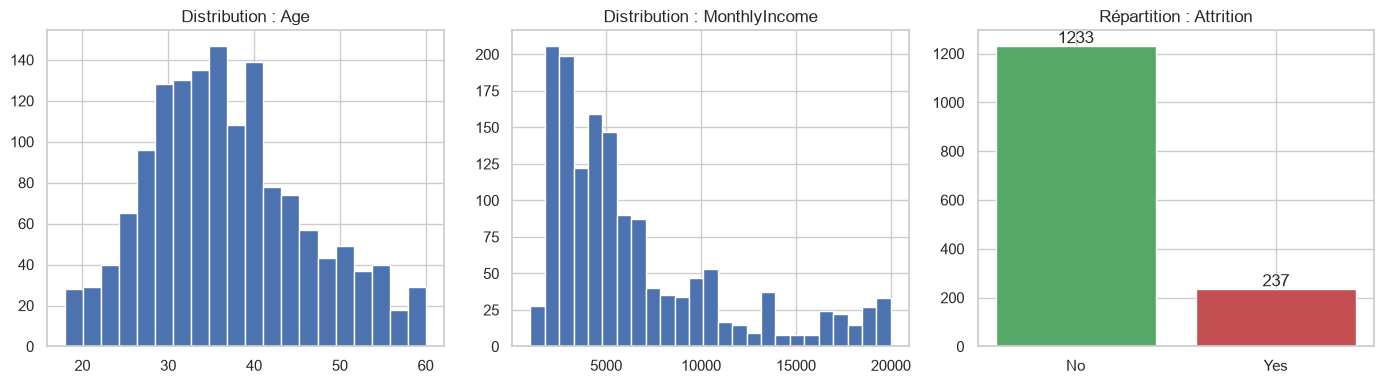

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["Age"], bins=20, color="#4C72B0")
axes[0].set_title("Distribution : Age")

axes[1].hist(df["MonthlyIncome"], bins=25, color="#4C72B0")
axes[1].set_title("Distribution : MonthlyIncome")

attrition_counts = df["Attrition"].value_counts()
axes[2].bar(attrition_counts.index, attrition_counts.values, color=["#55A868", "#C44E52"])
axes[2].set_title("Répartition : Attrition")
for i, v in enumerate(attrition_counts.values):
    axes[2].text(i, v + 10, str(v), ha="center")

plt.tight_layout()
plt.savefig("../reports/univarie_distributions.png", dpi=150)
plt.show()

In [7]:
display(Markdown(
    "**Observations** `Age` suit une distribution proche de la normale, centrée sur la mi-trentaine. "
    "`MonthlyIncome` est nettement asymétrique à droite (quelques hauts salaires tirent la moyenne au-dessus "
    "de la médiane), c'est pour ça que les comparaisons de revenu plus loin dans ce notebook utilisent la "
    "médiane plutôt que la moyenne. La classe `Attrition` est déséquilibrée (83,9 % / 16,1 %), ce qui justifie "
    "les tests non paramétriques (Mann-Whitney) plutôt qu'un test qui suppose des groupes de taille comparable."
))

**Observations** `Age` suit une distribution proche de la normale, centrée sur la mi-trentaine. `MonthlyIncome` est nettement asymétrique à droite (quelques hauts salaires tirent la moyenne au-dessus de la médiane), c'est pour ça que les comparaisons de revenu plus loin dans ce notebook utilisent la médiane plutôt que la moyenne. La classe `Attrition` est déséquilibrée (83,9 % / 16,1 %), ce qui justifie les tests non paramétriques (Mann-Whitney) plutôt qu'un test qui suppose des groupes de taille comparable.

**Bivarié**

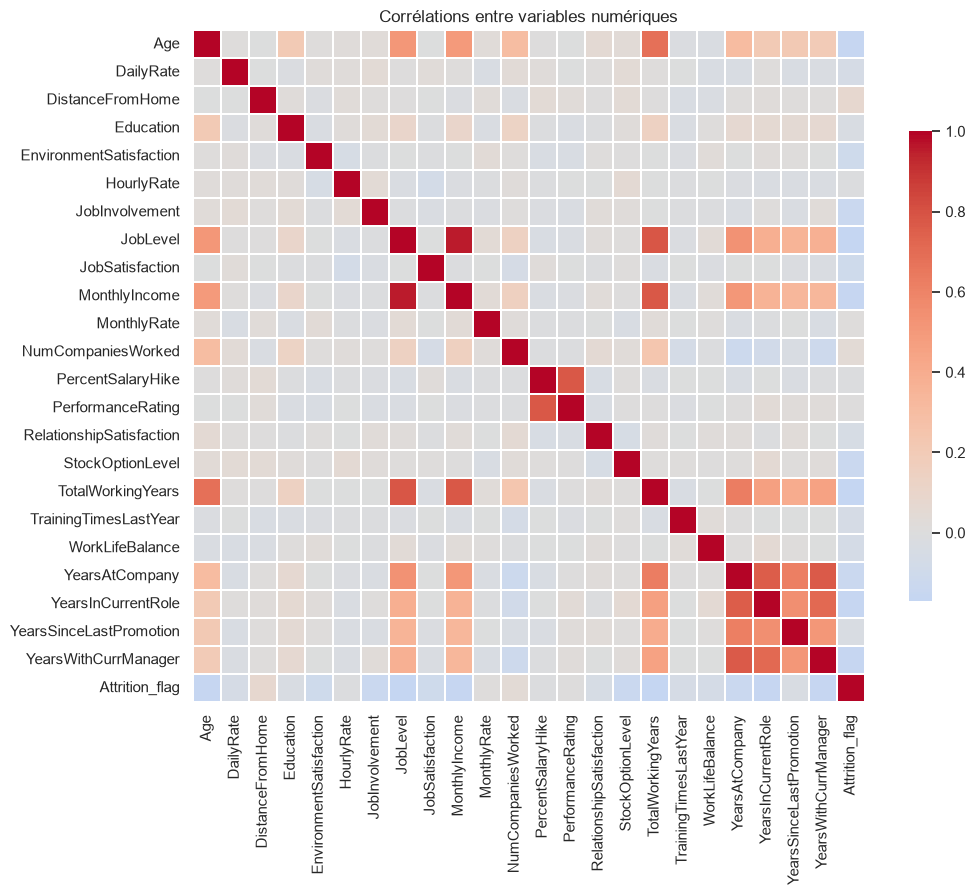

In [8]:
num_cols = df.select_dtypes(include="number").columns.drop("EmployeeNumber")
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3, ax=ax,
            cbar_kws={"shrink": 0.7})
ax.set_title("Corrélations entre variables numériques")
plt.tight_layout()
plt.savefig("../reports/bivarie_correlation_heatmap.png", dpi=150)
plt.show()

In [9]:
# paires de variables les plus corrélées hors diagonale (et hors doublons symétriques)
corr_unstacked = corr.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]
top_pairs = corr_unstacked.sort_values(ascending=False).drop_duplicates().head(3)
top_pairs

MonthlyIncome      JobLevel             0.950300
TotalWorkingYears  JobLevel             0.782208
PerformanceRating  PercentSalaryHike    0.773550
dtype: float64

In [10]:
top_pair = top_pairs.index[0]
top_val = top_pairs.iloc[0]

display(Markdown(
    f"**Observations** La corrélation la plus forte du jeu de données est entre `{top_pair[0]}` et "
    f"`{top_pair[1]}` (`{top_val:.2f}`), ce qui est logique : le revenu suit directement le niveau "
    f"hiérarchique. `Age` est aussi corrélé à `TotalWorkingYears`, `JobLevel` et `MonthlyIncome` : ces "
    f"variables ne sont pas indépendantes, un point à garder en tête pour le modèle de risque du notebook 02, "
    f"où des variables corrélées peuvent rendre l'importance de chacune moins lisible individuellement."
))

**Observations** La corrélation la plus forte du jeu de données est entre `MonthlyIncome` et `JobLevel` (`0.95`), ce qui est logique : le revenu suit directement le niveau hiérarchique. `Age` est aussi corrélé à `TotalWorkingYears`, `JobLevel` et `MonthlyIncome` : ces variables ne sont pas indépendantes, un point à garder en tête pour le modèle de risque du notebook 02, où des variables corrélées peuvent rendre l'importance de chacune moins lisible individuellement.

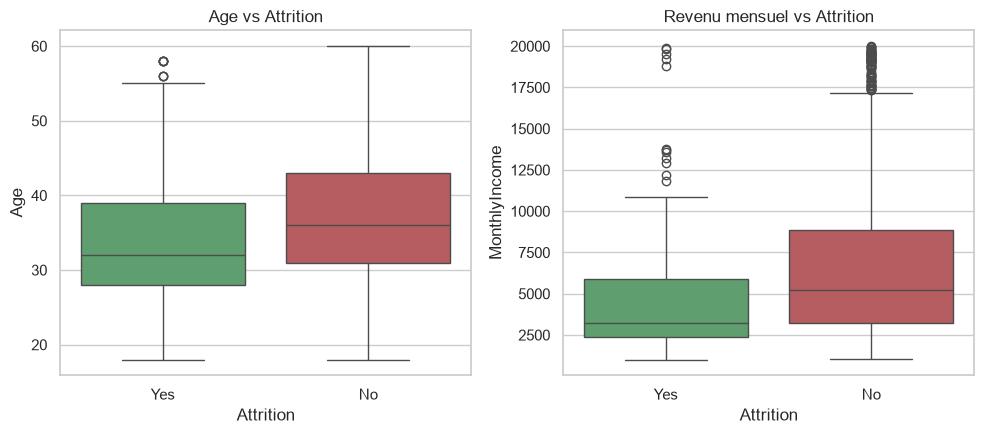

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sns.boxplot(data=df, x="Attrition", y="Age", hue="Attrition", ax=axes[0], palette=["#55A868", "#C44E52"], legend=False)
axes[0].set_title("Age vs Attrition")

sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", hue="Attrition", ax=axes[1], palette=["#55A868", "#C44E52"], legend=False)
axes[1].set_title("Revenu mensuel vs Attrition")

plt.tight_layout()
plt.savefig("../reports/bivarie_age_revenu_attrition.png", dpi=150)
plt.show()

In [12]:
age_median_yes = df.loc[df["Attrition"] == "Yes", "Age"].median()
age_median_no = df.loc[df["Attrition"] == "No", "Age"].median()
income_median_yes = df.loc[df["Attrition"] == "Yes", "MonthlyIncome"].median()
income_median_no = df.loc[df["Attrition"] == "No", "MonthlyIncome"].median()

display(Markdown(
    f"**Observations** Âge médian : `{age_median_yes:.0f}` ans chez les partants contre `{age_median_no:.0f}` "
    f"chez les restants, les collaborateurs qui partent sont plus jeunes. Revenu médian : `{income_median_yes:.0f}` "
    f"contre `{income_median_no:.0f}`, un écart net. Les deux différences semblent marquées, mais `Age` et "
    f"`MonthlyIncome` sont corrélés à `JobLevel`/`TotalWorkingYears` (heatmap ci-dessus) : le test statistique "
    f"formel, en section 7 avec les autres facteurs, permet de confirmer si l'écart tient au-delà du simple "
    f"coup d'œil."
))

**Observations** Âge médian : `32` ans chez les partants contre `36` chez les restants, les collaborateurs qui partent sont plus jeunes. Revenu médian : `3202` contre `5204`, un écart net. Les deux différences semblent marquées, mais `Age` et `MonthlyIncome` sont corrélés à `JobLevel`/`TotalWorkingYears` (heatmap ci-dessus) : le test statistique formel, en section 7 avec les autres facteurs, permet de confirmer si l'écart tient au-delà du simple coup d'œil.

# 5. Requêtage SQL

Je requête directement en SQL les deux premiers KPIs d'attrition.

In [13]:
con = duckdb.connect()
con.register("employees", df)

attrition_by_dept = con.execute('''
    SELECT
        Department,
        COUNT(*) AS effectif,
        SUM(Attrition_flag) AS departs,
        ROUND(SUM(Attrition_flag) * 1.0 / COUNT(*), 4) AS taux_attrition
    FROM employees
    GROUP BY Department
    ORDER BY taux_attrition DESC
''').df().set_index("Department")

attrition_by_dept

,effectif,departs,taux_attrition
Department,,,
Sales,446,92.0,0.2063
Human Resources,63,12.0,0.1905
Research & Development,961,133.0,0.1384


In [14]:
attrition_by_role = con.execute('''
    SELECT
        JobRole,
        COUNT(*) AS effectif,
        SUM(Attrition_flag) AS departs,
        ROUND(SUM(Attrition_flag) * 1.0 / COUNT(*), 4) AS taux_attrition
    FROM employees
    GROUP BY JobRole
    ORDER BY taux_attrition DESC
''').df().set_index("JobRole")

attrition_by_role

,effectif,departs,taux_attrition
JobRole,,,
Sales Representative,83,33.0,0.3976
Laboratory Technician,259,62.0,0.2394
Human Resources,52,12.0,0.2308
Sales Executive,326,57.0,0.1748
Research Scientist,292,47.0,0.1610
Manufacturing Director,145,10.0,0.0690
Healthcare Representative,131,9.0,0.0687
Manager,102,5.0,0.0490
Research Director,80,2.0,0.0250


Le reste du notebook réutilise ces deux tables pour les visualisations.

# 6. KPI attrition par département et par poste

Le taux est présenté avec l'effectif sous-jacent, pas comme un pourcentage brut qui masquerait les petits effectifs.

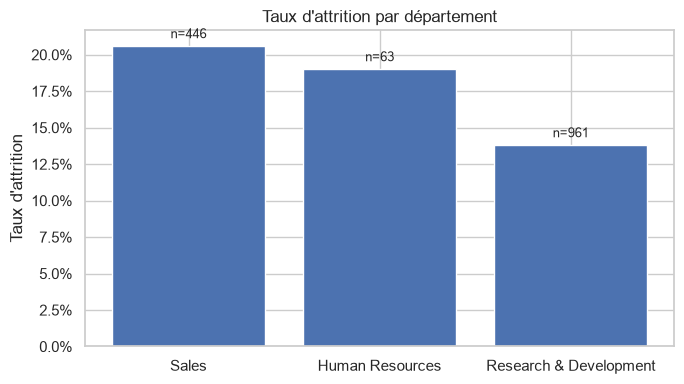

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(attrition_by_dept.index, attrition_by_dept["taux_attrition"], color="#4C72B0")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Taux d'attrition")
ax.set_title("Taux d'attrition par département")
for bar, effectif in zip(bars, attrition_by_dept["effectif"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"n={effectif}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/kpi_attrition_par_departement.png", dpi=150)
plt.show()

In [16]:
worst_dept = attrition_by_dept.index[0]
worst_rate = attrition_by_dept.loc[worst_dept, "taux_attrition"]
best_dept = attrition_by_dept.index[-1]
best_rate = attrition_by_dept.loc[best_dept, "taux_attrition"]

display(Markdown(
    f"**Observations** Le taux d'attrition va de `{best_rate:.1%}` ({best_dept}) à "
    f"`{worst_rate:.1%}` ({worst_dept}). L'effectif (`n=`) est affiché sur chaque barre : un taux élevé "
    f"sur un petit effectif se lit différemment d'un taux élevé sur un gros effectif."
))

**Observations** Le taux d'attrition va de `13.8%` (Research & Development) à `20.6%` (Sales). L'effectif (`n=`) est affiché sur chaque barre : un taux élevé sur un petit effectif se lit différemment d'un taux élevé sur un gros effectif.

# 7. Facteurs associés à l'attrition

Je croise l'attrition avec cinq facteurs, chacun testé statistiquement plutôt que comparé à l'œil. `Age` et `MonthlyIncome` sont inclus malgré leur corrélation avec `JobLevel`/`TotalWorkingYears` (vue en section 4) : un test univarié reste informatif, la réserve sur la corrélation est juste à garder en tête pour ne pas sur-interpréter chaque facteur comme un effet indépendant.

In [17]:
from scipy.stats import chi2_contingency, mannwhitneyu

def test_categoriel(col):
    table = pd.crosstab(df[col], df["Attrition"])
    chi2, p, dof, _ = chi2_contingency(table)
    return p

def test_continu(col):
    a = df.loc[df["Attrition"] == "Yes", col]
    b = df.loc[df["Attrition"] == "No", col]
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    return p

facteurs = pd.DataFrame({
    "facteur": ["OverTime (catégoriel)", "JobSatisfaction (ordinal)", "YearsSinceLastPromotion (continu)",
                "Age (continu)", "MonthlyIncome (continu)"],
    "test": ["Chi²", "Chi²", "Mann-Whitney U", "Mann-Whitney U", "Mann-Whitney U"],
    "p_value": [
        test_categoriel("OverTime"),
        test_categoriel("JobSatisfaction"),
        test_continu("YearsSinceLastPromotion"),
        test_continu("Age"),
        test_continu("MonthlyIncome"),
    ],
})
facteurs["significatif (p<0.05)"] = facteurs["p_value"] < 0.05
facteurs

,facteur,test,p_value,significatif (p<0.05)
0,OverTime (catégoriel),Chi²,8.158424e-21,True
1,JobSatisfaction (ordinal),Chi²,5.563005e-04,True
2,YearsSinceLastPromotion (continu),Mann-Whitney U,4.117911e-02,True
3,Age (continu),Mann-Whitney U,5.304342e-11,True
4,MonthlyIncome (continu),Mann-Whitney U,2.950831e-14,True


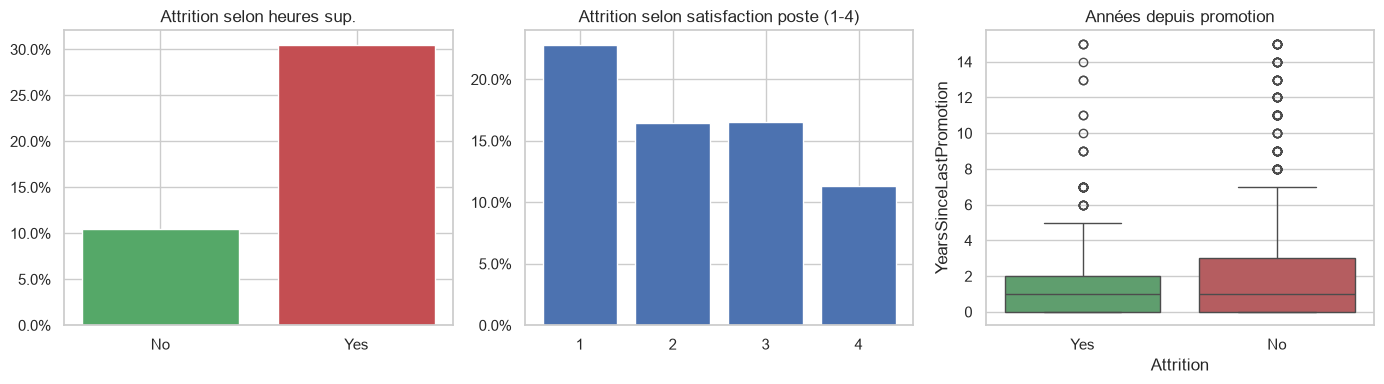

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

overtime_rate = df.groupby("OverTime")["Attrition_flag"].mean()
axes[0].bar(overtime_rate.index, overtime_rate.values, color=["#55A868", "#C44E52"])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_title("Attrition selon heures sup.")

satisf_rate = df.groupby("JobSatisfaction")["Attrition_flag"].mean()
axes[1].bar(satisf_rate.index.astype(str), satisf_rate.values, color="#4C72B0")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_title("Attrition selon satisfaction poste (1-4)")

sns.boxplot(data=df, x="Attrition", y="YearsSinceLastPromotion", hue="Attrition", ax=axes[2], palette=["#55A868", "#C44E52"], legend=False)
axes[2].set_title("Années depuis promotion")

plt.tight_layout()
plt.savefig("../reports/kpi_facteurs_attrition.png", dpi=150)
plt.show()

In [19]:
display(Markdown(
    "**Observations** Les cinq p-values sont affichées dans le tableau au-dessus : "
    "en dessous de 0.05, l'association observée n'est pas qu'un effet du hasard "
    "d'échantillonnage. Ça ne veut pas dire que ces facteurs *causent* le départ, juste qu'ils y sont "
    "statistiquement associés. `Age` et `MonthlyIncome` étant corrélés à `JobLevel`/`TotalWorkingYears`, "
    "une partie de leur signal ici peut recouper ce que ces autres variables expliquent déjà, pas un effet "
    "strictement indépendant."
))

**Observations** Les cinq p-values sont affichées dans le tableau au-dessus : en dessous de 0.05, l'association observée n'est pas qu'un effet du hasard d'échantillonnage. Ça ne veut pas dire que ces facteurs *causent* le départ, juste qu'ils y sont statistiquement associés. `Age` et `MonthlyIncome` étant corrélés à `JobLevel`/`TotalWorkingYears`, une partie de leur signal ici peut recouper ce que ces autres variables expliquent déjà, pas un effet strictement indépendant.

# 8. Équité salariale par genre, à niveau de poste équivalent

Je contrôle par niveau de poste : une moyenne brute non contrôlée serait trompeuse si la répartition hommes/femmes n'est pas la même à chaque niveau.

In [20]:
income_by_level_gender = (
    df.groupby(["JobLevel", "Gender"])["MonthlyIncome"]
    .median()
    .unstack()
)
income_by_level_gender["écart (F - M)"] = income_by_level_gender["Female"] - income_by_level_gender["Male"]
income_by_level_gender["écart en %"] = income_by_level_gender["écart (F - M)"] / income_by_level_gender["Male"]
income_by_level_gender

Gender,Female,Male,écart (F - M),écart en %
JobLevel,,,,
1,2659.0,2678.5,-19.5,-0.007280
2,5247.5,5383.5,-136.0,-0.025262
3,10052.0,9854.0,198.0,0.020093
4,16064.0,16328.0,-264.0,-0.016169
5,19071.5,19246.0,-174.5,-0.009067


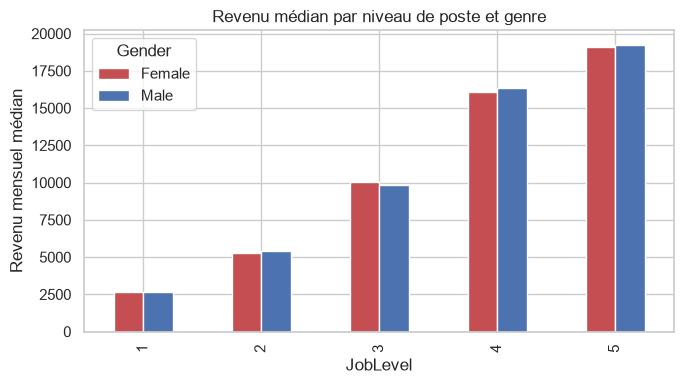

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
income_by_level_gender[["Female", "Male"]].plot(kind="bar", ax=ax, color=["#C44E52", "#4C72B0"])
ax.set_ylabel("Revenu mensuel médian")
ax.set_title("Revenu médian par niveau de poste et genre")
plt.tight_layout()
plt.savefig("../reports/kpi_equite_salariale.png", dpi=150)
plt.show()

In [22]:
max_gap = income_by_level_gender["écart en %"].abs().max()
level_max_gap = income_by_level_gender["écart en %"].abs().idxmax()

display(Markdown(
    f"**Observations** À niveau de poste équivalent, l'écart médian le plus marqué est au "
    f"niveau `{level_max_gap}` (`{income_by_level_gender.loc[level_max_gap, 'écart en %']:.1%}`). "
    f"Le contrôle par `JobLevel` change la lecture par rapport à une moyenne brute globale."
))

**Observations** À niveau de poste équivalent, l'écart médian le plus marqué est au niveau `2` (`-2.5%`). Le contrôle par `JobLevel` change la lecture par rapport à une moyenne brute globale.

# 9. Bien-être par département

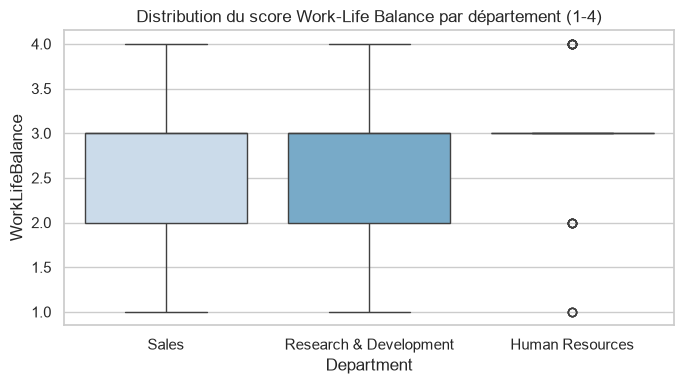

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="Department", y="WorkLifeBalance", hue="Department", ax=ax, palette="Blues", legend=False)
ax.set_title("Distribution du score Work-Life Balance par département (1-4)")
plt.tight_layout()
plt.savefig("../reports/kpi_worklife_balance.png", dpi=150)
plt.show()

# 10. Deux questions ad hoc

La direction RH me pose aussi des questions ponctuelles, en dehors du backlog planifié. Deux exemples traités ici : la distance domicile-travail par poste, et le revenu selon le niveau d'études, croisés avec l'attrition.

In [24]:
distance_by_role = (
    df.groupby(["JobRole", "Attrition"])["DistanceFromHome"]
    .mean()
    .unstack()
)
distance_by_role["écart (Yes - No)"] = distance_by_role["Yes"] - distance_by_role["No"]
distance_by_role.sort_values("écart (Yes - No)", ascending=False).round(1)

Attrition,No,Yes,écart (Yes - No)
JobRole,,,
Healthcare Representative,9.2,17.7,8.5
Human Resources,6.6,13.4,6.8
Sales Executive,9.0,12.6,3.6
Manager,7.9,10.0,2.1
Research Scientist,8.9,9.8,0.9
Laboratory Technician,9.3,9.7,0.3
Manufacturing Director,9.5,8.8,-0.7
Sales Representative,9.0,8.2,-0.8
Research Director,8.5,7.0,-1.5


In [25]:
worst_commute_role = distance_by_role["écart (Yes - No)"].idxmax()
worst_commute_gap = distance_by_role.loc[worst_commute_role, "écart (Yes - No)"]

display(Markdown(
    f"**Observations** Sur `{worst_commute_role}`, les collaborateurs partis habitaient en "
    f"moyenne `{worst_commute_gap:.1f}` km plus loin que ceux restés. L'écart n'est pas uniforme selon les "
    f"postes : sur d'autres postes, la distance ne varie presque pas entre partants et restants, ce qui "
    f"suggère un effet localisé à certains métiers plutôt qu'un effet général de la distance domicile-travail."
))

**Observations** Sur `Healthcare Representative`, les collaborateurs partis habitaient en moyenne `8.5` km plus loin que ceux restés. L'écart n'est pas uniforme selon les postes : sur d'autres postes, la distance ne varie presque pas entre partants et restants, ce qui suggère un effet localisé à certains métiers plutôt qu'un effet général de la distance domicile-travail.

In [26]:
education_labels = {1: "Below College", 2: "College", 3: "Bachelor", 4: "Master", 5: "Doctor"}
df["EducationLabel"] = df["Education"].map(education_labels)

income_by_education = (
    df.groupby(["EducationLabel", "Attrition"])["MonthlyIncome"]
    .median()
    .unstack()
)
income_by_education["écart en %"] = (income_by_education["No"] - income_by_education["Yes"]) / income_by_education["No"]
income_by_education["No"] = income_by_education["No"].round(0)
income_by_education["Yes"] = income_by_education["Yes"].round(0)
income_by_education["écart en %"] = (income_by_education["écart en %"] * 100).round(1)
income_by_education

Attrition,No,Yes,écart en %
EducationLabel,,,
Bachelor,5210.0,2863.0,45.0
Below College,3977.0,3041.0,23.5
College,4998.0,2924.0,41.5
Doctor,6272.0,6134.0,2.2
Master,5464.0,4445.0,18.6


In [27]:
gap_min_level = income_by_education["écart en %"].idxmin()
gap_min = income_by_education["écart en %"].min()
gap_max_level = income_by_education["écart en %"].idxmax()
gap_max = income_by_education["écart en %"].max()

display(Markdown(
    f"**Observations** L'écart de revenu médian entre partants et restants varie fortement selon le niveau "
    f"d'études : quasi nul chez `{gap_min_level}` (`{gap_min:.1f}%`), jusqu'à `{gap_max:.1f}%` chez "
    f"`{gap_max_level}`. Contrairement à l'écart par genre (section précédente), celui-ci n'est pas stable "
    f"d'un niveau à l'autre, ce qui suggère que le revenu pèse sur la décision de partir surtout pour "
    f"certains profils, pas de façon uniforme."
))

**Observations** L'écart de revenu médian entre partants et restants varie fortement selon le niveau d'études : quasi nul chez `Doctor` (`2.2%`), jusqu'à `45.0%` chez `Bachelor`. Contrairement à l'écart par genre (section précédente), celui-ci n'est pas stable d'un niveau à l'autre, ce qui suggère que le revenu pèse sur la décision de partir surtout pour certains profils, pas de façon uniforme.

# 11. Synthèse

Le taux d'attrition est ventilé par département et par poste plutôt que réduit à un chiffre unique, cinq facteurs associés à l'attrition sont testés statistiquement (dont deux, `Age` et `MonthlyIncome`, repérés dans l'analyse bivariée puis testés formellement plutôt que laissés en simple observation visuelle), l'écart salarial est contrôlé par niveau de poste, un indicateur de bien-être est calculé par département, et deux questions ad hoc (distance domicile-travail, revenu par niveau d'études) sont traitées avec le même niveau de rigueur que les KPIs planifiés. L'analyse univariée et bivariée en amont a orienté ces choix méthodologiques (médiane plutôt que moyenne, tests non paramétriques) plutôt que de les laisser arbitraires. Le catalogue de données (`DATA_CATALOG.md`) et le guide utilisateur (`USER_GUIDE.md`) accompagnent ces résultats.

**Limites.** Le jeu de données est fictif, généré par IBM pour démontrer Watson Analytics, pas une extraction d'un vrai SIRH : les corrélations trouvées ici illustrent la méthode, elles ne constituent pas un diagnostic RH réel et ne doivent pas être présentées comme tel. Le requêtage est fait en DuckDB plutôt que sur un entrepôt Snowflake, faute d'accès à cet outil en dehors d'un contexte d'entreprise.

**Prochaines étapes** : brancher ce pipeline sur une source de données rafraîchie automatiquement plutôt qu'un CSV statique, transformer les visualisations matplotlib en dashboard Power BI interactif, et un notebook complémentaire (`02_attrition_risk_model.ipynb`) pousse la question plus loin avec un modèle de risque par collaborateur.